In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# AdaBoost Model
from sklearn.ensemble import AdaBoostClassifier

# Uncomment below if using XGBoost
# from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# Generate artificial classification dataset

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (500, 2)
Target Shape  : (500,)


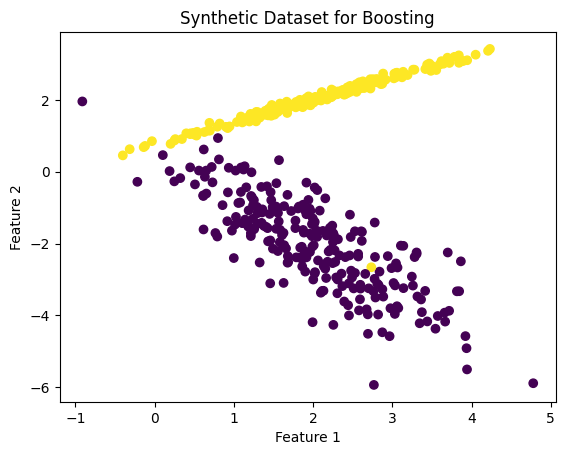

In [3]:
plt.scatter(X[:,0], X[:,1], c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Dataset for Boosting")

plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (400, 2)
Testing Shape  : (100, 2)


In [5]:
model = AdaBoostClassifier(
    n_estimators=100,     # Number of weak learners
    learning_rate=1.0,
    random_state=42
)

In [6]:
# First install:
# pip install xgboost

# Uncomment import:
# from xgboost import XGBClassifier

"""
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
"""

'\nmodel = XGBClassifier(\n    n_estimators=100,\n    learning_rate=0.1,\n    max_depth=3,\n    random_state=42\n)\n'

In [7]:
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [8]:
y_pred = model.predict(X_test)

print("Predicted Values :")
print(y_pred)

Predicted Values :
[1 1 0 1 0 1 0 1 0 1 1 0 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0
 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 1 0 0 0 1 1
 1 0 0 1 0 1 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 1]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report :")
print(classification_report(y_test, y_pred))

Accuracy : 0.98

Confusion Matrix :
[[50  1]
 [ 1 48]]

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        51
           1       0.98      0.98      0.98        49

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



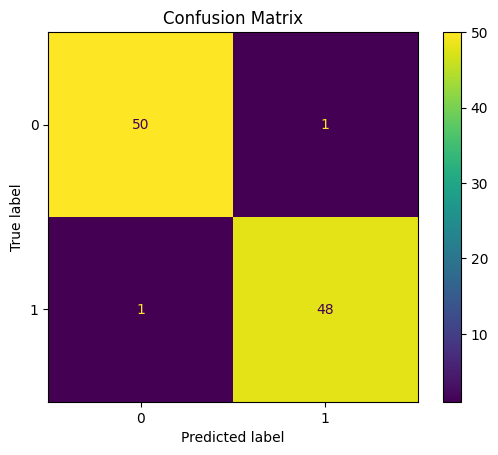

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")

plt.show()

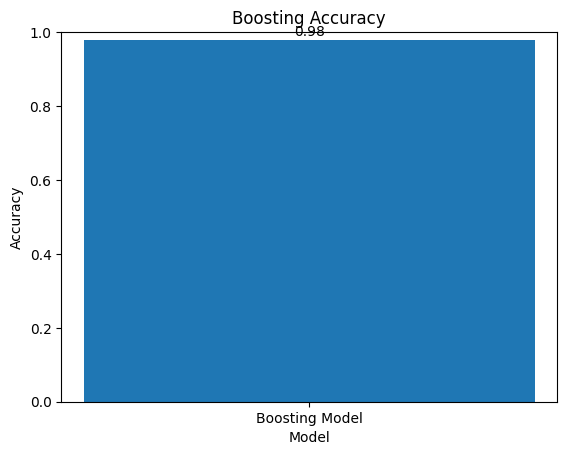

In [11]:
models = ["Boosting Model"]
accuracies = [accuracy]

plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Boosting Accuracy")

plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')

plt.show()

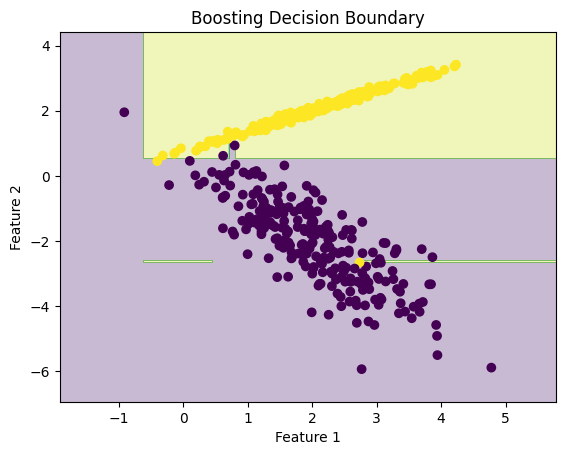

In [12]:
def plot_decision_boundary(X, y, model):

    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X[:,0], X[:,1], c=y)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Boosting Decision Boundary")

    plt.show()


plot_decision_boundary(X, y, model)

In [13]:
new_data = [[1.5, -0.5]]

prediction = model.predict(new_data)

print("Prediction for New Data :", prediction)

Prediction for New Data : [0]
